# Chorus TF-IDF Song Recommender

## 1. Imports & Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chorus_preprocessing import preprocess_chorus
from chorus_recommender import build_chorus_recommender, recommend_songs
from tfidf_recommender import (
    build_tfidf_recommender,
    recommend_songs as tfidf_recommend
)

pd.set_option('display.max_colwidth', 60)
print('Imports successful.')

Imports successful.


## 2. Preprocess Chorus Data

In [2]:
chorus_df = preprocess_chorus(
    raw_lyrics_path='../data/raw/lyrics.csv',
    output_path='../data/processed/chorus_clean.csv'
)
chorus_df.head()

Songs with chorus tag:    1138/1856 (61.3%)
Songs using fallback:     718/1856 (38.7%)
Saved to ../data/processed/chorus_clean.csv


,track_id,track_name,artist,lyrics,chorus_text,processed_chorus,chorus_fallback,token_count
0,0qNnE0beu4OfHk8Txa3vGt,Soul Flower - Remix,The Pharcyde,"[Chorus]\nEe, ah, ooh, ah, ah, ee, ah, ooh, ah, ah\nEe, ...","Ee, ah, ooh, ah, ah, ee, ah, ooh, ah, ah\nEe, ah, ooh, a...",ee ah ooh ah ah ee ah ooh ah ah ee ah ooh ah ah ee ah oo...,False,60
1,7AHX0F99w4x23uSZihklZ6,My God,Tapir!,[Verse 1]\nWaking up with intuition\nGoing back to sleep...,But don't let it break you\nThere's no complications\nIt...,dont let break there complication imagination dont let b...,False,17
2,1KbpVvPiLAt1Wsh5gr2YKM,Take a Trip,TV Girl,"[Intro]\nTake, take, take a trip, take a trip back down\...",It's not something you can point to\nIt's not something ...,point hold heaven know heaven know happens world point h...,False,65
3,56s4IHGnJVGZYcdOVmC3eb,"I Love Life, Thank You",Mac Miller,"[Intro]\nAlright then, bitch\nHa, ya\nUh\nA million moth...","Ayo, this where the hook be\nBut I ain't got no hook, yo...",ayo hook aint got hook pussy said hook bitch aint got fu...,False,26
4,5XufqHphZkJhIkc5wlEST7,Soft Rock Band,Good Morning,[Intro]\nWell I played time in exile\nAnd the weather it...,"Oh, I might have seen it all\nBut I know, oh, there's st...",oh seen know oh there oh oh seen know there yeah know se...,False,26


In [3]:
# Corpus summary
n_total    = len(chorus_df)
n_fallback = chorus_df['chorus_fallback'].sum()
n_chorus   = n_total - n_fallback

print(f"Total songs in corpus:   {n_total}")
print(f"With chorus tag:         {n_chorus} ({n_chorus/n_total:.1%})")
print(f"Fallback (full lyrics):  {n_fallback} ({n_fallback/n_total:.1%})")
print()
print("Token count distribution (chorus only):")
print(chorus_df['token_count'].describe().round(1))

Total songs in corpus:   1856
With chorus tag:         1138 (61.3%)
Fallback (full lyrics):  718 (38.7%)

Token count distribution (chorus only):
count      1856.0
mean        757.1
std        6130.2
min          10.0
25%          33.0
50%          56.0
75%          97.0
max      220054.0
Name: token_count, dtype: float64


## 3. Chorus Extraction Inspection

In [4]:
def inspect_song(track_name, artist=None):
    matches = chorus_df[chorus_df['track_name'].str.lower() == track_name.lower()]
    if artist:
        matches = matches[matches['artist'].str.lower() == artist.lower()]
    if matches.empty:
        print(f"'{track_name}' not found.")
        return
    row = matches.iloc[0]
    print(f"Track:           {row['track_name']} — {row['artist']}")
    print(f"Fallback:        {row['chorus_fallback']}")
    print(f"Token count:     {row['token_count']}")
    print(f"\nRaw chorus text:\n{str(row['chorus_text'])[:600]}")
    print(f"\nProcessed:       {str(row['processed_chorus'])[:300]}")

# Check each of your 4 seed songs
inspect_song('Iron Clad Lou',  'Hum')
print('\n' + '='*70 + '\n')
inspect_song('Can I Help You?',     'Amnesty')
print('\n' + '='*70 + '\n')
inspect_song('Los Libros de la Buena Memoria', 'Invisible')
print('\n' + '='*70 + '\n')
inspect_song('House Money',    'Baby Keem')
print('\n' + '='*70 + '\n')

Track:           Iron Clad Lou — Hum
Fallback:        False
Token count:     16

Raw chorus text:
I win, I win, I win
It sure gets lonely at the top
It sure feels weird, you're falling out
It sure gets lonely at the top
I win, I win

Processed:       win win win sure get lonely sure feel weird youre falling sure get lonely win win


Track:           Can I Help You? — Amnesty
Fallback:        True
Token count:     68

Raw chorus text:
Love is the sweetest amnesty
Floats like a cloud between the sky and sea
I'll give it to you, could you please give it to me?
Love is the sweetest amnesty
Given by the powers then let us be
I'll give it to you, could you please give it to me?
'Cause I need you
We can talk, we can see
If we disagree we do it honestly
Let our lovin' be the sweetest amnesty
Between you and me there's bound to be
Some conscientious objection
Our spirits dressed in mystery speak solely through affection
Between you and me there's bound to be
Some conscientious objection
Our spi

## 4. Full Lyrics vs Chorus Only Tokens

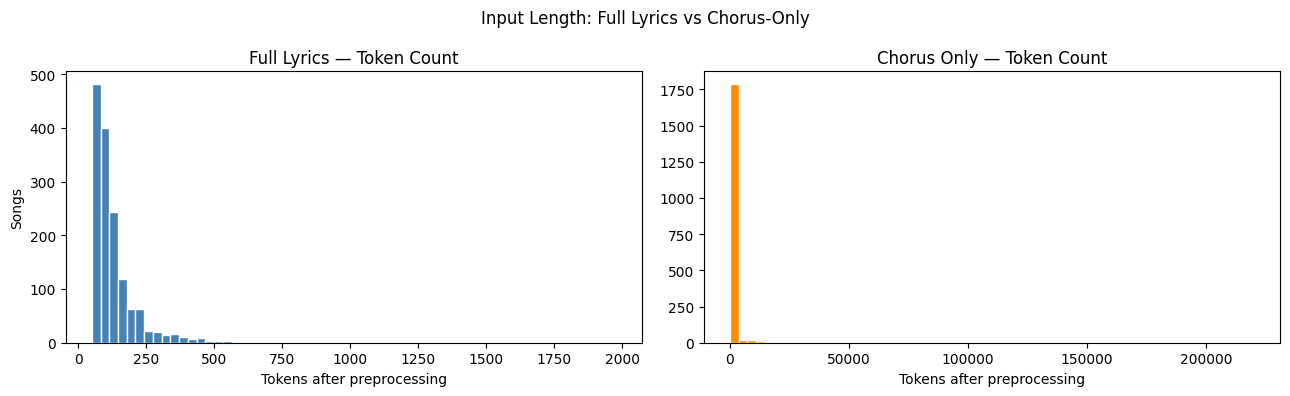

Full lyrics token stats:
count    1503.0
mean      146.2
std       186.1
min        50.0
25%        76.0
50%       102.0
75%       147.5
max      1975.0
Name: token_count, dtype: float64

Chorus-only token stats:
count      1856.0
mean        757.1
std        6130.2
min          10.0
25%          33.0
50%          56.0
75%          97.0
max      220054.0
Name: token_count, dtype: float64


In [6]:
full_df = pd.read_csv('../data/processed/lyrics_clean.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

axes[0].hist(full_df['token_count'],   bins=60, color='steelblue',  edgecolor='white')
axes[0].set_title('Full Lyrics — Token Count')
axes[0].set_xlabel('Tokens after preprocessing')
axes[0].set_ylabel('Songs')

axes[1].hist(chorus_df['token_count'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Chorus Only — Token Count')
axes[1].set_xlabel('Tokens after preprocessing')

plt.suptitle('Input Length: Full Lyrics vs Chorus-Only')
plt.tight_layout()
plt.show()

print("Full lyrics token stats:")
print(full_df['token_count'].describe().round(1))
print("\nChorus-only token stats:")
print(chorus_df['token_count'].describe().round(1))

## 5. Recommenders

In [7]:
# Chorus model
chorus_df_model, chorus_tfidf, chorus_sim, chorus_vec = build_chorus_recommender(
    '../data/processed/chorus_clean.csv'
)

# Full-lyric TF-IDF baseline
full_df_model, full_tfidf, full_sim = build_tfidf_recommender(
    '../data/processed/lyrics_clean.csv'
)

print(f"Chorus corpus size:    {len(chorus_df_model)} songs")
print(f"Full lyric corpus:     {len(full_df_model)} songs")
print(f"Chorus TF-IDF matrix:  {chorus_tfidf.shape}")
print(f"Full TF-IDF matrix:    {full_tfidf.shape}")

Chorus corpus size:    1856 songs
Full lyric corpus:     1503 songs
Chorus TF-IDF matrix:  (1856, 10000)
Full TF-IDF matrix:    (1503, 10000)


## 6. Recommendation Comparison

In [8]:
def compare_models(seed_title, seed_artist=None, k=10):
    """Print full-lyric TF-IDF and chorus-only recommendations side by side."""
    try:
        full_recs = tfidf_recommend(
            full_df_model, full_sim,
            seed_title=seed_title, seed_artist=seed_artist, k=k
        ).rename(columns={'similarity': 'full_score'})
    except ValueError:
        print(f"[NOT FOUND in full corpus] '{seed_title}'")
        return None, None

    try:
        chorus_recs = recommend_songs(
            chorus_df_model, chorus_sim,
            seed_title=seed_title, seed_artist=seed_artist, k=k
        ).rename(columns={'similarity': 'chorus_score'})
    except ValueError:
        print(f"[NOT FOUND in chorus corpus] '{seed_title}'")
        return None, None

    full_recs.index   += 1
    chorus_recs.index += 1

    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    print(f"{'Rank':<5} {'── Full Lyrics ──':<46} {'── Chorus Only ──':<46}")
    print('-' * 97)
    for i in range(1, k + 1):
        f = full_recs.loc[i]
        c = chorus_recs.loc[i]
        fb = ' *' if c.get('chorus_fallback', False) else ''
        f_str = f"{f['track_name'][:28]} — {f['artist'][:12]} ({f['full_score']:.3f})"
        c_str = f"{c['track_name'][:28]} — {c['artist'][:12]} ({c['chorus_score']:.3f}){fb}"
        print(f"{i:<5} {f_str:<46} {c_str:<46}")
    print('  * = chorus fallback (full lyrics used)')

    return full_recs, chorus_recs

In [9]:
# --- Grunge ---
full_grunge, chorus_grunge = compare_models('Iron Clad Lou', seed_artist='Hum')


Seed: 'Iron Clad Lou' by Hum
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     Stand up and Win — Spymob (0.145)              Stand up and Win — Spymob (0.300) *           
2     Never Lonely — Space Mounta (0.135)            Faxing It In — Smushie (0.286)                
3     Downtown — Varsity (0.123)                     UFO — The Juice Is (0.200)                    
4     Hippies — flipturn (0.121)                     Belief — John Mayer (0.193)                   
5     Rain — World's Expe (0.120)                    Arabella — Arctic Monke (0.172)               
6     Faxing It In — Smushie (0.112)                 Scar Tissue — Red Hot Chil (0.169)            
7     2023 — Blue Rain Bo (0.107)                    Alright — Supergrass (0.165)                  
8     Warmest Part of the Winter — Voxtrot (0.107)   The Great Salt Lake

In [10]:
# --- Soul ---
full_soul, chorus_soul = compare_models("Can I Help You?", seed_artist='Amnesty')


Seed: 'Can I Help You?' by Amnesty
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     Sweetest Thing on This Side  — Papa Bear &  (0.307) Wizard Of Finance — Parliament (0.259)        
2     Chicago — Michael Jack (0.171)                 Chicago — Michael Jack (0.255)                
3     Bailee — The Licks (0.161)                     Ellie — Make Friends (0.221)                  
4     Wizard Of Finance — Parliament (0.149)         City Blues — The Walters (0.176)              
5     Cause = Time — Broken Socia (0.143)            Let's Straighten It Out — O.V. Wright (0.170) 
6     Mystery Girl — Housecall (0.123)               I Love You — Steve Miller (0.166) *           
7     Ellie — Make Friends (0.118)                   New Jacket — Literature (0.152)               
8     Hard To Handle — The Black Cr (0.098)          Hey, Who

In [11]:
# --- Latin ---
full_latin, chorus_latin = compare_models(
    'Los Libros de la Buena Memoria', seed_artist='Invisible'
)


Seed: 'Los Libros de la Buena Memoria' by Invisible
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     My Conception — Ryo Fukui (0.653)              My Conception — Ryo Fukui (0.748) *           
2     SMUCKERS (feat. Lil Wayne &  — Tyler, The C (0.491) Las Habladurias del Mundo — Pescado Rabi (0.641) *
3     Las Habladurias del Mundo — Pescado Rabi (0.451) SMUCKERS (feat. Lil Wayne &  — Tyler, The C (0.572) *
4     After The Storm (feat. Tyler — Kali Uchis (0.439) Como Mata el Viento Norte — La Maquina D (0.556) *
5     Oh Qué Será? — Willie Colón (0.409)            After The Storm (feat. Tyler — Kali Uchis (0.512) *
6     Como Mata el Viento Norte — La Maquina D (0.408) Lo Que Nos Ocupa Es Esa Abue — Invisible (0.504) *
7     Promesas Sobre El Bidet — Charly Garcí (0.358) Elementales Leches — Invisible (0.452) *      
8     ･－･･ ･ 

In [12]:
# --- Hip-hop ---
full_hiphop, chorus_hiphop = compare_models('House Money', seed_artist='Baby Keem')


Seed: 'House Money' by Baby Keem
Rank  ── Full Lyrics ──                              ── Chorus Only ──                             
-------------------------------------------------------------------------------------------------
1     Jesus Is The One (I Got Depr — Zack Fox (0.435) Blood On Me — Sampha (0.218)                  
2     Can You Rap Like Me? — Trippie Redd (0.363)    The Killing Moon — Echo & the B (0.188)       
3     Hit Bout It — Lil Yachty (0.329)               Tried And True — Ween (0.186)                 
4     Blood On Me — Sampha (0.321)                   I Love Life, Thank You — Mac Miller (0.166)   
5     REEL IT IN — Aminé (0.286)                     A Rose Blooms in Chaos — Davishmar (0.162) *  
6     trademark usa — Baby Keem (0.272)              Hilary $Wank — Joey Bada$$ (0.157) *          
7     JayJay-Z — Zelooperz (0.266)                   Watermelon — John + Jane  (0.153)             
8     Fresh Prince Of Utah — YoungBoy Nev (0.262)    fafo — Zack Fo

## 7. Overlap: Full Lyrics vs Chorus

In [13]:
def overlap_stats(full_recs, chorus_recs, label):
    if full_recs is None or chorus_recs is None:
        print(f"{label}: skipped (not found)\n")
        return
    full_set   = set(zip(full_recs['track_name'],   full_recs['artist']))
    chorus_set = set(zip(chorus_recs['track_name'], chorus_recs['artist']))
    shared   = full_set & chorus_set
    jaccard  = len(shared) / len(full_set | chorus_set)
    print(f"{label}")
    print(f"  Shared songs:   {len(shared)}/10")
    print(f"  Jaccard score:  {jaccard:.2f}")
    if shared:
        print(f"  Overlap:        {', '.join([s[0] for s in shared])}")
    print()

overlap_stats(full_grunge,  chorus_grunge,  'Grunge  (Iron Clad Lou)')
overlap_stats(full_soul,    chorus_soul,    'Soul    (Can I Help You?)')
overlap_stats(full_latin,   chorus_latin,   'Latin   (Los Libros...)')
overlap_stats(full_hiphop,  chorus_hiphop,  'Hip-hop (House Money)')

Grunge  (Iron Clad Lou)
  Shared songs:   2/10
  Jaccard score:  0.11
  Overlap:        Stand up and Win, Faxing It In

Soul    (Can I Help You?)
  Shared songs:   5/10
  Jaccard score:  0.33
  Overlap:        Wizard Of Finance, Chicago, Hard To Handle, Hey, Who Really Cares, Ellie

Latin   (Los Libros...)
  Shared songs:   8/10
  Jaccard score:  0.67
  Overlap:        My Conception, Las Habladurias del Mundo, SMUCKERS (feat. Lil Wayne & Kanye West), Elementales Leches, Promesas Sobre El Bidet, After The Storm (feat. Tyler, The Creator & Bootsy Collins), Oh Qué Será?, Como Mata el Viento Norte

Hip-hop (House Money)
  Shared songs:   1/10
  Jaccard score:  0.05
  Overlap:        Blood On Me



## 8. Similarity Score Distribution: Full vs Chorus

Songs in both corpora: 1486


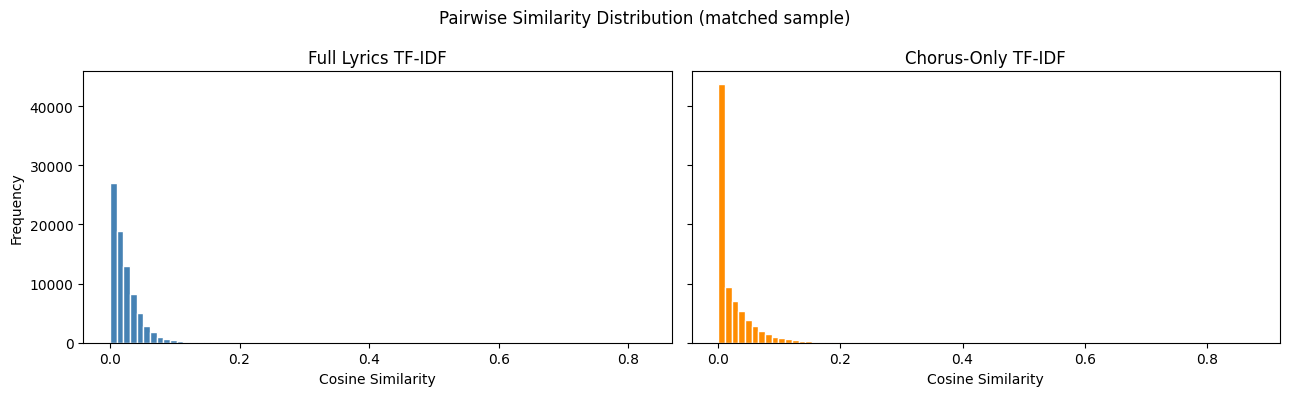

Full lyrics:  mean=0.0231  median=0.0169  >0.1: 1.3%  >0.3: 0.0%
Chorus only:  mean=0.0226  median=0.0073  >0.1: 4.0%  >0.3: 0.1%


In [14]:
# Use only songs present in both corpora for a fair comparison
shared_songs = set(zip(full_df_model['track_name'], full_df_model['artist'])) & \
               set(zip(chorus_df_model['track_name'], chorus_df_model['artist']))
print(f"Songs in both corpora: {len(shared_songs)}")

sample_size = min(400, len(shared_songs))
rng = np.random.default_rng(42)

# Get indices in each DataFrame for the shared sample
shared_list = list(shared_songs)
sample_songs = [shared_list[i] for i in rng.choice(len(shared_list), sample_size, replace=False)]

def get_indices(df, song_list):
    idx = []
    for name, artist in song_list:
        match = df[(df['track_name'] == name) & (df['artist'] == artist)]
        if not match.empty:
            idx.append(match.index[0])
    return idx

full_idx   = get_indices(full_df_model,   sample_songs)
chorus_idx = get_indices(chorus_df_model, sample_songs)

n = min(len(full_idx), len(chorus_idx))
full_sample   = full_sim[np.ix_(full_idx[:n],   full_idx[:n])]
chorus_sample = chorus_sim[np.ix_(chorus_idx[:n], chorus_idx[:n])]

full_upper   = full_sample[np.triu_indices(n, k=1)]
chorus_upper = chorus_sample[np.triu_indices(n, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].hist(full_upper,   bins=80, color='steelblue',  edgecolor='white')
axes[0].set_title('Full Lyrics TF-IDF')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')

axes[1].hist(chorus_upper, bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Chorus-Only TF-IDF')
axes[1].set_xlabel('Cosine Similarity')

plt.suptitle('Pairwise Similarity Distribution (matched sample)')
plt.tight_layout()
plt.show()

for label, arr in [('Full lyrics', full_upper), ('Chorus only', chorus_upper)]:
    print(f"{label}:  mean={arr.mean():.4f}  median={np.median(arr):.4f}  "
          f">0.1: {(arr > 0.1).mean()*100:.1f}%  >0.3: {(arr > 0.3).mean()*100:.1f}%")

## 9. Fallback Analysis

In [15]:
fallbacks = chorus_df[chorus_df['chorus_fallback'] == True]
print(f"Total fallback songs: {len(fallbacks)}\n")
print("Top 15 artists with the most fallback songs:")
print(fallbacks['artist'].value_counts().head(15).to_string())

Total fallback songs: 718

Top 15 artists with the most fallback songs:
artist
The Smiths            39
Oasis                  8
Chet Baker             5
Led Zeppelin           5
Bob Dylan              5
Spymob                 4
Jimi Hendrix           4
Electrelane            4
Zelooperz              4
Heatmiser              4
Yoko Ono               4
Hum                    4
Good Morning           4
Frank Sinatra          3
Tyler, The Creator     3


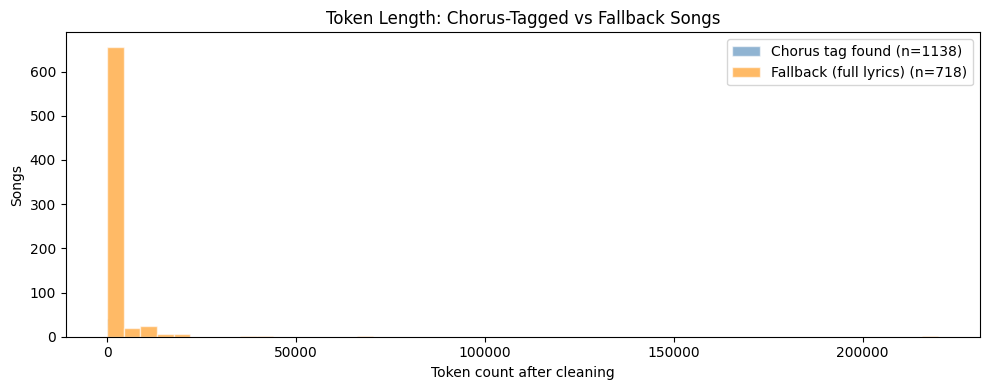

In [16]:
# Are fallback songs shorter or longer than chorus-tagged songs?
fig, ax = plt.subplots(figsize=(10, 4))
for flag, label, color in [(False, 'Chorus tag found', 'steelblue'),
                            (True,  'Fallback (full lyrics)', 'darkorange')]:
    subset = chorus_df[chorus_df['chorus_fallback'] == flag]['token_count']
    ax.hist(subset, bins=50, alpha=0.6, label=f"{label} (n={len(subset)})",
            color=color, edgecolor='white')
ax.set_xlabel('Token count after cleaning')
ax.set_ylabel('Songs')
ax.set_title('Token Length: Chorus-Tagged vs Fallback Songs')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Observations & Notes